# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources (README.md file)
- Happy learning!

In [39]:
# import numpy and pandas
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import trim_mean, mode, skew, gaussian_kde, pearsonr, spearmanr, beta
from statsmodels.stats.weightstats import ztest as ztest

from scipy.stats import ttest_ind, norm, t
from scipy.stats import f_oneway
from scipy.stats import sem
import matplotlib.pyplot as plt

# Challenge 1 - Exploring the Data

In this challenge, we will examine all salaries of employees of the City of Chicago. We will start by loading the dataset and examining its contents

In [3]:
# Run this code:
salaries = pd.read_csv('../data/Current_Employee_Names__Salaries__and_Position_Titles.csv')

Examine the `salaries` dataset using the `head` function below.

### Data examination

In [4]:
salaries.head()

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
0,"AARON, JEFFERY M",SERGEANT,POLICE,F,Salary,NaN,101442.0,NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),POLICE,F,Salary,NaN,94122.0,NaN
2,"AARON, KIMBERLEI R",CHIEF CONTRACT EXPEDITER,GENERAL SERVICES,F,Salary,NaN,101592.0,NaN
3,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,WATER MGMNT,F,Salary,NaN,110064.0,NaN
4,"ABASCAL, REECE E",TRAFFIC CONTROL AIDE-HOURLY,OEMC,P,Hourly,20.0,NaN,19.86


In [5]:
salaries.describe()

,Typical Hours,Annual Salary,Hourly Rate
count,8022.000000,25161.000000,8022.000000
mean,34.507604,86786.999790,32.788558
std,9.252077,21041.354602,12.112573
min,10.000000,7200.000000,2.650000
25%,20.000000,76266.000000,21.200000
50%,40.000000,90024.000000,35.600000
75%,40.000000,96060.000000,40.200000
max,40.000000,300000.000000,109.000000


In [6]:
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33183 entries, 0 to 33182
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               33183 non-null  object 
 1   Job Titles         33183 non-null  object 
 2   Department         33183 non-null  object 
 3   Full or Part-Time  33183 non-null  object 
 4   Salary or Hourly   33183 non-null  object 
 5   Typical Hours      8022 non-null   float64
 6   Annual Salary      25161 non-null  float64
 7   Hourly Rate        8022 non-null   float64
dtypes: float64(3), object(5)
memory usage: 2.0+ MB


In [8]:
salaries.columns = [col.lower().replace(" ", "_") for col in salaries.columns]

In [9]:
salaries.head()

,name,job_titles,department,full_or_part-time,salary_or_hourly,typical_hours,annual_salary,hourly_rate
0,"AARON, JEFFERY M",SERGEANT,POLICE,F,Salary,NaN,101442.0,NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),POLICE,F,Salary,NaN,94122.0,NaN
2,"AARON, KIMBERLEI R",CHIEF CONTRACT EXPEDITER,GENERAL SERVICES,F,Salary,NaN,101592.0,NaN
3,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,WATER MGMNT,F,Salary,NaN,110064.0,NaN
4,"ABASCAL, REECE E",TRAFFIC CONTROL AIDE-HOURLY,OEMC,P,Hourly,20.0,NaN,19.86


# Challenge 2 - Hypothesis Tests

In this section of the lab, we will test whether the hourly wage of all hourly workers is significantly different from $30/hr. Import the correct one sample test function from scipy and perform the hypothesis test for a 95% two sided confidence interval.

In [40]:
import seaborn as sns

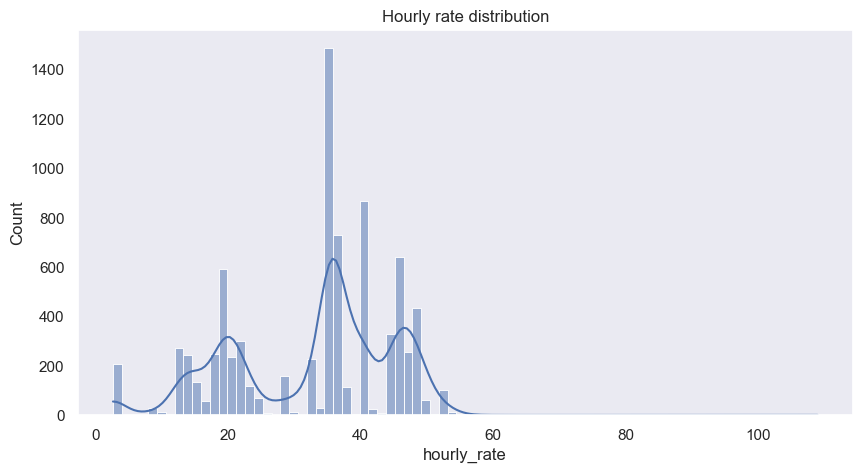

In [45]:
#Filter the hourly workers and their hourly_rate. 
filter1=salaries['hourly_rate'].loc[(salaries['salary_or_hourly'] == 'Hourly')]
filter1

plt.figure(figsize=(10, 5))
plt.title('Hourly rate distribution')
sns.set_theme(style="dark")
sns.histplot(
    data=filter1,
    bins=80,
    kde=True
)
plt.show()


In [ ]:
#Setting up the hypothesis testing: 
#H0 = mean = 30/h, this is the status quo that we are looking to interrogate with the new data.
#Hal= mean =! 30/h
R1 = stats.ttest_1samp(filter1,30)
R1

TtestResult(statistic=np.float64(20.6198057854942), pvalue=np.float64(4.323024048623005e-92), df=np.int64(8021))

In [ ]:
#For a confidence interval of 95% (alpha = 0.05) if p < alpha, null hypothesis is rejected.
R1.pvalue < 0.05

np.True_

In [32]:
#The outcome gives a p value of 4.32x10^-92, the value is extremely small and would indicate that the null hypothesis is rejected, so the actual mean of the sample is far from 30.
#Confirming: 
mean1 = filter1.mean()
mean1

np.float64(32.78855771628024)

In [31]:
print("The hourly wage of all hourly workers is different than $30/h.")

The hourly wage of all hourly workers is different than $30/h.


# Challenge 3 - Constructing Confidence Intervals

While testing our hypothesis is a great way to gather empirical evidence for accepting or rejecting the hypothesis, another way to gather evidence is by creating a confidence interval. A confidence interval gives us information about the true mean of the population. So for a 95% confidence interval, we are 95% sure that the mean of the population is within the confidence interval. 
).

To read more about confidence intervals, click [here](https://en.wikipedia.org/wiki/Confidence_interval).


In the cell below, we will construct a 95% confidence interval for the mean hourly wage of all hourly workers. 

The confidence interval is computed in SciPy using the `t.interval` function. You can read more about this function [here](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.t.html).

To compute the confidence interval of the hourly wage, use the 0.95 for the confidence level, number of rows - 1 for degrees of freedom, the mean of the sample for the location parameter and the standard error for the scale. The standard error can be computed using [this](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html) function in SciPy.

In [ ]:
#STD
dof1 = len(filter1)-1
std1= stats.sem(a= filter1, ddof=dof1) #a for array and ddof for degrees of freedom
std1

np.float64(12.111817701093825)

In [ ]:
#Creating the confidence interval 
R2 = t.interval(0.95,dof1,mean1,std1)
R2

(np.float64(9.04624854199394), np.float64(56.530866890566536))

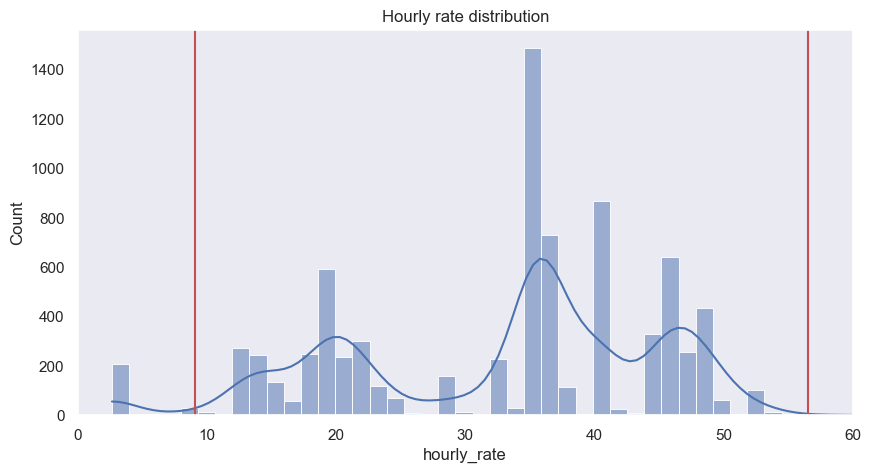

In [ ]:

#Plot with the confidence intervals
plt.figure(figsize=(10, 5))
plt.title('Hourly rate distribution')
sns.set_theme(style="dark")
sns.histplot(
    data=filter1,
    bins=80,
    kde=True
)
plt.axvline(R2[0], color='r')
plt.axvline(R2[1], color = 'r')
plt.xlim(0,60)
plt.show()

# Challenge 4 - Hypothesis Tests of Proportions

Another type of one sample test is a hypothesis test of proportions. In this test, we examine whether the proportion of a group in our sample is significantly different than a fraction. 

You can read more about one sample proportion tests [here](http://sphweb.bumc.bu.edu/otlt/MPH-Modules/BS/SAS/SAS6-CategoricalData/SAS6-CategoricalData2.html).

In the cell below, use the `proportions_ztest` function from `statsmodels` to perform a hypothesis test that will determine whether the number of hourly workers in the City of Chicago is significantly different from 25% at the 95% confidence level.

In [83]:
#Main question: Is the number of hourly workers in the City of Chicago significantly different from 25% at the 95% confidence level? 
#There are only two types of categories: hourly or salary
filter2 = salaries['salary_or_hourly'].value_counts(normalize = "column")
filter2


salary_or_hourly
Salary    0.75825
Hourly    0.24175
Name: proportion, dtype: float64

In [82]:
#To extract the proportion of the hourly workers over the salary ones 
filter2.iloc[1]

np.float64(24.17502938251514)

In [ ]:

from statsmodels.stats.proportion import proportions_ztest

In [94]:
#Proportions ztest
count = len(filter1) #8022
nobs = len(salaries["salary_or_hourly"])#33183
value = 0.25
zstat, pval  = proportions_ztest(count,nobs,value)
print(f"Z-statistic: {zstat:.4f}, P-value: {pval:.4f}")

Z-statistic: -3.5100, P-value: 0.0004


Considering that we were using a 0.95 interval of confidence, the p-value is much smaller than the significance level of 0.05, so the null hypothesis is rejected. 
Which means, that the number of hourly workers in the City of Chicago with an hourly salary is different than 25 %. In fact, the value is only 24%. 